# EDA CDC Places Dataset  

## Introduction

The Centers for Disease Control and Prevention (CDC) provides a dataset called "Places" that contains information about various health-related metrics at the county and city level across the United States. This dataset includes information on health outcomes, health behaviors, clinical care, social and economic factors, and physical environment.

This exploratory data analysis (EDA) focuses on understanding the structure of the CDC Places dataset, to identify patterns, trends, and potential areas for further analysis that can support the master dataset join. Key objectives include validating primary keys, identifying data quality issues (such as missingness), and assessing the distribution of core health metrics.

**Updated Version of the CDC Dataset**: The dataset has been updated to include age-adjusted rates for various health outcomes, which allows for more accurate comparisons across different populations. This update enhances the dataset's utility for public health research and policy-making.

## Import Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

# Read The CSV file 

In [2]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw"/ "cdc_places_aa_raw.csv"

df = pd.read_csv(data_path)

print(f"Data loaded successfully")

Data loaded successfully


<positron-console-cell-2>:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.


In the CDC data, columns like countyfips or various demographic flags might contain both numbers (e.g., 6065) and potentially some "N/A" strings or leading zeros that cause the data type to switch from an int to an object/string.

In [3]:
# Specify columns explicitly
# Replace 'countyfips' with the actual column name that has mixed types
dtypes = {
    'countyfips': str,      # FIPS should always be a string to preserve leading zeros
    'bphigh_adjprev': float # Prevalence is a percentage
}

df = pd.read_csv(data_path, dtype=dtypes)

<positron-console-cell-3>:8: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.


Datatype warning is not coming from FIPS column 

In [4]:
# Peek at the columns to see what indices 10 and 11 are
cols = pd.read_csv(data_path, nrows=0).columns
print(f"Column 10: {cols[10]}")
print(f"Column 11: {cols[11]}")

Column 10: data_value_footnote_symbol
Column 11: data_value_footnote


These are messy columns, likly with a majority of null values. 

Since these are metadata/footnote columns, they likely won't be needed for actual machine-learning math anyway. The cleanest solution is to force them to strings so they don't interfere with your numeric data.

In [5]:
# Read the file by forcing the footnote columns to strings
df = pd.read_csv(
    data_path, 
    dtype={
        'data_value_footnote_symbol': str, 
        'data_value_footnote': str
    }
)

# Exploratory Data Analysis (EDA)

In [6]:
df.head()

,year,stateabbr,statedesc,locationname,datasource,category,measure,data_value_unit,data_value_type,data_value,...,low_confidence_limit,high_confidence_limit,totalpopulation,totalpop18plus,locationid,categoryid,measureid,datavaluetypeid,short_question_text,geolocation
0,2023,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Age-adjusted prevalence,11.5,...,11.2,11.9,334914895,262083034,59,PREVENT,ACCESS2,AgeAdjPrv,Health Insurance,NaN
1,2023,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults,%,Age-adjusted prevalence,21.9,...,21.6,22.1,334914895,262083034,59,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,NaN
2,2023,US,United States,NaN,BRFSS,Health Risk Behaviors,Binge drinking among adults,%,Age-adjusted prevalence,16.6,...,16.3,16.9,334914895,262083034,59,RISKBEH,BINGE,AgeAdjPrv,Binge Drinking,NaN
3,2023,US,United States,NaN,BRFSS,Health Outcomes,High blood pressure among adults,%,Age-adjusted prevalence,30.7,...,30.4,31.0,334914895,262083034,59,HLTHOUT,BPHIGH,AgeAdjPrv,High Blood Pressure,NaN
4,2023,US,United States,NaN,BRFSS,Prevention,Taking medicine to control high blood pressure...,%,Age-adjusted prevalence,57.5,...,56.8,58.2,334914895,262083034,59,PREVENT,BPMED,AgeAdjPrv,High Blood Pressure Medication,NaN


In [7]:
df.shape

(114649, 22)

This dataset has less features compared to the other CDC dataset previously downloaded. This is beacuse this dataset uses Wide Data instead of Long Data. Wide data has more columns and less rows. Long data has more rows and less columns. Wide data is GIS-friendly. 

This dataset will allow for cleaner merging, freatures ready for machine learning, and spatial integrity. 

In [8]:
print(df.columns)

Index(['year', 'stateabbr', 'statedesc', 'locationname', 'datasource',
       'category', 'measure', 'data_value_unit', 'data_value_type',
       'data_value', 'data_value_footnote_symbol', 'data_value_footnote',
       'low_confidence_limit', 'high_confidence_limit', 'totalpopulation',
       'totalpop18plus', 'locationid', 'categoryid', 'measureid',
       'datavaluetypeid', 'short_question_text', 'geolocation'],
      dtype='object')


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,114649.0,2022.862842,3.440153e-01,2022.0,2023.0,2023.0,2023.0,2023.0
data_value,114616.0,25.264020,2.122481e+01,1.7,9.5,17.8,33.3,90.4
low_confidence_limit,114616.0,22.318931,1.999225e+01,1.5,7.9,15.0,28.6,88.9
high_confidence_limit,114616.0,28.323929,2.240775e+01,2.0,11.3,20.8,38.3,91.8
totalpopulation,114649.0,223455.162138,6.261834e+06,43.0,10581.0,25915.0,69460.0,334914895.0
totalpop18plus,114649.0,174826.488194,4.900173e+06,30.0,8240.0,20528.0,54087.0,262083034.0
locationid,114649.0,30051.232353,1.526547e+04,59.0,18079.0,29151.0,45047.0,56045.0


The describe() output confirms the "Wide" structure by showing column-level summaries for the data.

The data_value Column: This confirms that the dataset is currently in a "Long-ish" format where data_value contains the measurement for the active metric, rather than having a column named bphigh_adjprev

In [10]:
df.isnull().sum()

year                               0
stateabbr                          0
statedesc                          0
locationname                      40
datasource                         0
category                           0
measure                            0
data_value_unit                    0
data_value_type                    0
data_value                        33
data_value_footnote_symbol    114609
data_value_footnote           114609
low_confidence_limit              33
high_confidence_limit             33
totalpopulation                    0
totalpop18plus                     0
locationid                         0
categoryid                         0
measureid                          0
datavaluetypeid                    0
short_question_text                0
geolocation                       40
dtype: int64

Drop footnote columns 

data_value	Drop Rows	Cannot predict hypertension without the data value.

locationname / geolocation	Likely minor reporting gaps; will disappear when you drop data_value rows.

In [11]:
# Drop the columns that are 99% empty
df = df.drop(columns=['data_value_footnote', 'data_value_footnote_symbol'])

# Drop the 33 rows where 'data_value' is missing
# (This will also likely clean up the other small NaN counts like locationname)
df = df.dropna(subset=['data_value'])

# Drop the technical/internal columns that add no value for ML
df = df.drop(columns=['categoryid', 'measureid', 'datavaluetypeid', 'short_question_text', 'geolocation', 'datasource'])

df.isnull().sum()

year                      0
stateabbr                 0
statedesc                 0
locationname             40
category                  0
measure                   0
data_value_unit           0
data_value_type           0
data_value                0
low_confidence_limit      0
high_confidence_limit     0
totalpopulation           0
totalpop18plus            0
locationid                0
dtype: int64

## Piviot the Dataframe

To merge the dataset a common key is needed. df_wide will have a row per county where a left_join can be performed with the master dataset. The data_value column will be pivoted into new columns for each metric, with the values being the corresponding data_value.

In [12]:
# Pivot the data to create columns for each measure
df_wide = df.pivot_table(
    index=['locationid', 'locationname', 'stateabbr'], 
    columns='measure', 
    values='data_value'
).reset_index()

# Now your columns will be the actual health measures (e.g., 'High blood pressure')
print(df_wide.columns)

Index(['locationid', 'locationname', 'stateabbr',
       'All teeth lost among adults aged >=65 years',
       'Any disability among adults', 'Arthritis among adults',
       'Binge drinking among adults',
       'Cancer (non-skin) or melanoma among adults',
       'Cholesterol screening among adults',
       'Chronic obstructive pulmonary disease among adults',
       'Cognitive disability among adults',
       'Colorectal cancer screening among adults aged 45–75 years',
       'Coronary heart disease among adults', 'Current asthma among adults',
       'Current cigarette smoking among adults',
       'Current lack of health insurance among adults aged 18-64 years',
       'Depression among adults', 'Diagnosed diabetes among adults',
       'Fair or poor self-rated health status among adults',
       'Food insecurity in the past 12 months among adults',
       'Frequent mental distress among adults',
       'Frequent physical distress among adults',
       'Hearing disability among ad

In [13]:
df = df_wide.copy()  # Use the wide format for further analysis

In [14]:
df.isnull().sum()

measure
locationid                                                                                0
locationname                                                                              0
stateabbr                                                                                 0
All teeth lost among adults aged >=65 years                                               0
Any disability among adults                                                             187
Arthritis among adults                                                                  187
Binge drinking among adults                                                             187
Cancer (non-skin) or melanoma among adults                                              187
Cholesterol screening among adults                                                      187
Chronic obstructive pulmonary disease among adults                                      187
Cognitive disability among adults                                       

The "0" counts: These measures (e.g., All teeth lost, Colorectal cancer screening, Short sleep duration) have zero missing values. Data is perfectly complete for these.

The "187" counts: These are standard health metrics (like High blood pressure). They have 187 missing rows across the entire dataset.

The "844" counts: These are social determinant metrics (like Food insecurity, Housing insecurity). They have 844 missing rows.

The remaining 187 and 844 counts of NaN (missing) values in the columns are now "feature gaps." In machine learning, will have to choose how to handle these before can train your hypertension model.

In [16]:
df.head()

measure,locationid,locationname,stateabbr,All teeth lost among adults aged >=65 years,Any disability among adults,Arthritis among adults,Binge drinking among adults,Cancer (non-skin) or melanoma among adults,Cholesterol screening among adults,Chronic obstructive pulmonary disease among adults,...,Obesity among adults,Received food stamps in the past 12 months among adults,Self-care disability among adults,Short sleep duration among adults,Stroke among adults,Taking medicine to control high blood pressure among adults with high blood pressure,Utility services shut-off threat in the past 12 months among adults,Vision disability among adults,Visited dentist or dental clinic in the past year among adults,Visits to doctor for routine checkup within the past year among adults
0,1001,Autauga,AL,12.0,32.4,26.3,15.6,7.0,85.0,6.4,...,39.5,11.6,3.6,37.7,3.2,61.7,8.8,4.8,61.9,79.4
1,1003,Baldwin,AL,11.4,31.4,26.3,17.1,7.6,84.9,6.0,...,35.0,9.1,3.2,36.4,2.9,59.1,7.2,4.3,62.4,77.5
2,1005,Barbour,AL,27.7,42.0,28.9,14.0,6.1,81.7,9.3,...,47.1,26.2,6.4,44.6,4.7,63.9,16.7,8.4,45.3,79.3
3,1007,Bibb,AL,21.7,39.6,28.2,15.3,6.9,81.5,8.9,...,43.7,18.7,5.1,41.4,4.0,61.6,12.0,6.7,50.2,77.3
4,1009,Blount,AL,16.8,35.8,26.7,16.3,7.3,82.4,7.6,...,36.0,12.1,4.0,37.6,3.3,58.9,8.3,5.3,54.0,77.0


In [15]:
df.dtypes

measure
locationid                                                                                int64
locationname                                                                             object
stateabbr                                                                                object
All teeth lost among adults aged >=65 years                                             float64
Any disability among adults                                                             float64
Arthritis among adults                                                                  float64
Binge drinking among adults                                                             float64
Cancer (non-skin) or melanoma among adults                                              float64
Cholesterol screening among adults                                                      float64
Chronic obstructive pulmonary disease among adults                                      float64
Cognitive disability among adult

All your measures are correctly formatted as float64 and are ready for mathematical operations 

Still have NaN values represented as float64 columns. 

In [17]:
# Check how many unique counties you have now
print(f"Total unique counties: {df_wide['locationid'].nunique()}")

# Ensure there are no rows that have ONLY NaNs (which would mean a failed pivot for that row)
print(f"Rows with all NaN values: {df_wide.drop(columns=['locationid', 'locationname', 'stateabbr']).isnull().all(axis=1).sum()}")

Total unique counties: 3143
Rows with all NaN values: 0


successfully created a robust, "wide" feature matrix, with 3,143 unique counties and zero rows composed entirely of NaNs

## Target Variable

The target variable for this analysis is the estimated prevalence of High blood pressure among adults (High blood pressure among adults), derived from the CDC PLACES dataset. These values represent model-based estimates generated via the Behavioral Risk Factor Surveillance System (BRFSS) and Census-level data.

Key Analytical Considerations:

    Nature of Data: These are statistically modeled estimates, not direct survey counts. They are designed for identifying broad geographic health disparities rather than evaluating the immediate impact of local interventions.

    Crude vs. Age-Adjusted: Our analysis will primarily utilize Age-Adjusted values. While "Crude" rates reflect the raw percentage of the population affected, age-adjusted rates normalize for differences in age distribution across counties, allowing for a fairer, more accurate comparison of health burdens between counties with different demographics.

    Granularity: With our data pivoted to the county level (locationid), we will examine the spatial distribution and variance of hypertension prevalence to identify trends that may serve as strong predictors for our risk stratification model.

In [19]:
# Descriptive statistics for target
# This tells you the min, max, mean, and spread of HBP across all 3,143 counties
target_col = 'High blood pressure among adults'
print(df_wide[target_col].describe())

count    2956.000000
mean       33.537483
std         4.654139
min        21.000000
25%        30.100000
50%        32.800000
75%        36.300000
max        53.100000
Name: High blood pressure among adults, dtype: float64


2,956 out of 3,143 counties reporting this data, which is a high completion rate—excellent for modeling

the mean is close to the median, indicating normal distribution. Models won't have to struggle to extream skewness. 

There is also a healthy amount of variance with a standard deviation of 4.65%. The model should have room to distinguish between high-risk and low risk counties. 

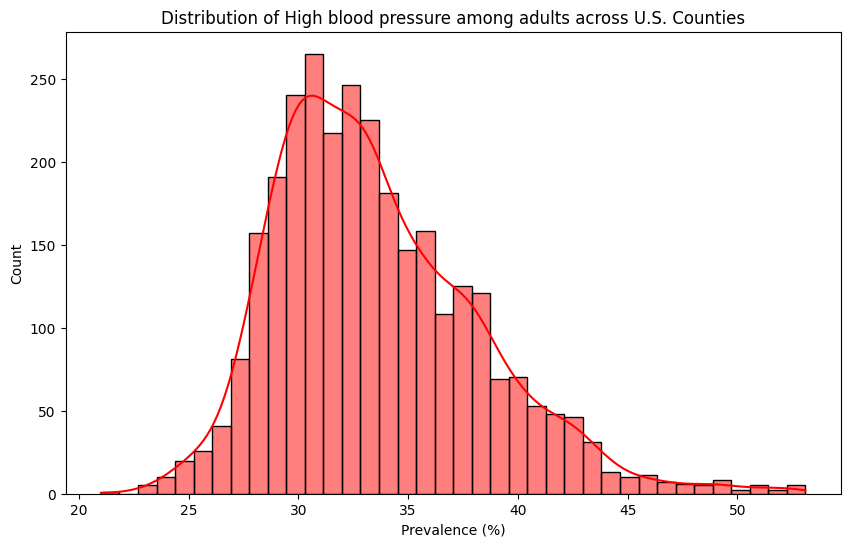

In [20]:
# Visualize the distribution

plt.figure(figsize=(10, 6))
sns.histplot(df_wide[target_col], kde=True, color='red')
plt.title(f'Distribution of {target_col} across U.S. Counties')
plt.xlabel('Prevalence (%)')
plt.show()

While the mean and median were very close, a simple summary statistic can sometimes hide asymmetry (skewness) or "fat tails" in the distribution. Data likly has high-prevalence outliers. 

While most counties hover in the 30% range, there is a distinct subset of counties suffering from significantly worse health outcomes, which is exactly what a "Risk Atlas" should highlight.

In [22]:
# Calculate skewness
skew_val = df_wide['High blood pressure among adults'].skew()
print(f"Skewness coefficient: {skew_val:.2f}")

Skewness coefficient: 0.83


In [21]:
# Quick check for outliers
# High-prevalence counties (Top 5)
print(df_wide.nlargest(5, target_col)[['locationname', 'stateabbr', target_col]])

measure  locationname stateabbr  High blood pressure among adults
1428           Holmes        MS                              53.1
1132     East Carroll        LA                              52.5
5             Bullock        AL                              52.4
31             Greene        AL                              52.4
1429        Humphreys        MS                              52.4


The high-prevalence counties represent some of the most concentrated areas of cardiovascular risk in the United States.

It is not a coincidence that these counties appear together at the top of the list. They are all situated within the "Stroke Belt" or the Mississippi Delta region, where historical, socio-economic, and environmental factors converge to create some of the nation's most persistent health disparities.